# 02 - Exploratory Data Analysis (EDA)

This notebook explores the merged Clinical + RNA-Seq dataset:
1. Dataset overview and summary statistics
2. Target class distribution
3. Clinical feature distributions
4. Gene expression overview
5. Correlation analysis
6. Feature variance analysis

> **Note:** All business logic is in `src/`. This notebook only orchestrates.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import config
from src.io import load_processed_clinical, save_figure, logger
from src.visualization import setup_style, plot_gene_heatmap

setup_style()

## Step 1: Load Merged Dataset

In [2]:
X = pd.read_csv(config.PROCESSED_DIR / "X_features_final.csv")
y = pd.read_csv(config.PROCESSED_DIR / "y_target_final.csv").iloc[:, 0]

print(f"Dataset shape: {X.shape}")
print(f"Samples: {len(X)}")
print(f"Features: {X.shape[1]}")
print(f"\nTarget distribution:")
print(y.value_counts().sort_index())
print(f"\nPositive rate: {y.mean():.2%}")

Dataset shape: (429, 19019)
Samples: 429
Features: 19019

Target distribution:
Biochemical_Recurrence_Code
0    371
1     58
Name: count, dtype: int64

Positive rate: 13.52%


## Step 2: Dataset Overview

In [3]:
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total samples:          {len(X)}")
print(f"Total features:         {X.shape[1]}")
print(f"Missing cells:          {int(X.isna().sum().sum()):,}")
print(f"Infinite cells:         {int(np.isinf(X.values).sum()):,}")
print(f"Positive cases (BCR=1): {int(y.sum())}")
print(f"Negative cases (BCR=0): {int((y == 0).sum())}")
print(f"Class imbalance ratio:  {(y == 0).sum() / max(y.sum(), 1):.1f}:1")

DATASET SUMMARY
Total samples:          429
Total features:         19019
Missing cells:          0
Infinite cells:         0
Positive cases (BCR=1): 58
Negative cases (BCR=0): 371
Class imbalance ratio:  6.4:1


## Step 3: Target Class Distribution

2026-09-15 00:03:07 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\eda_class_distribution.png


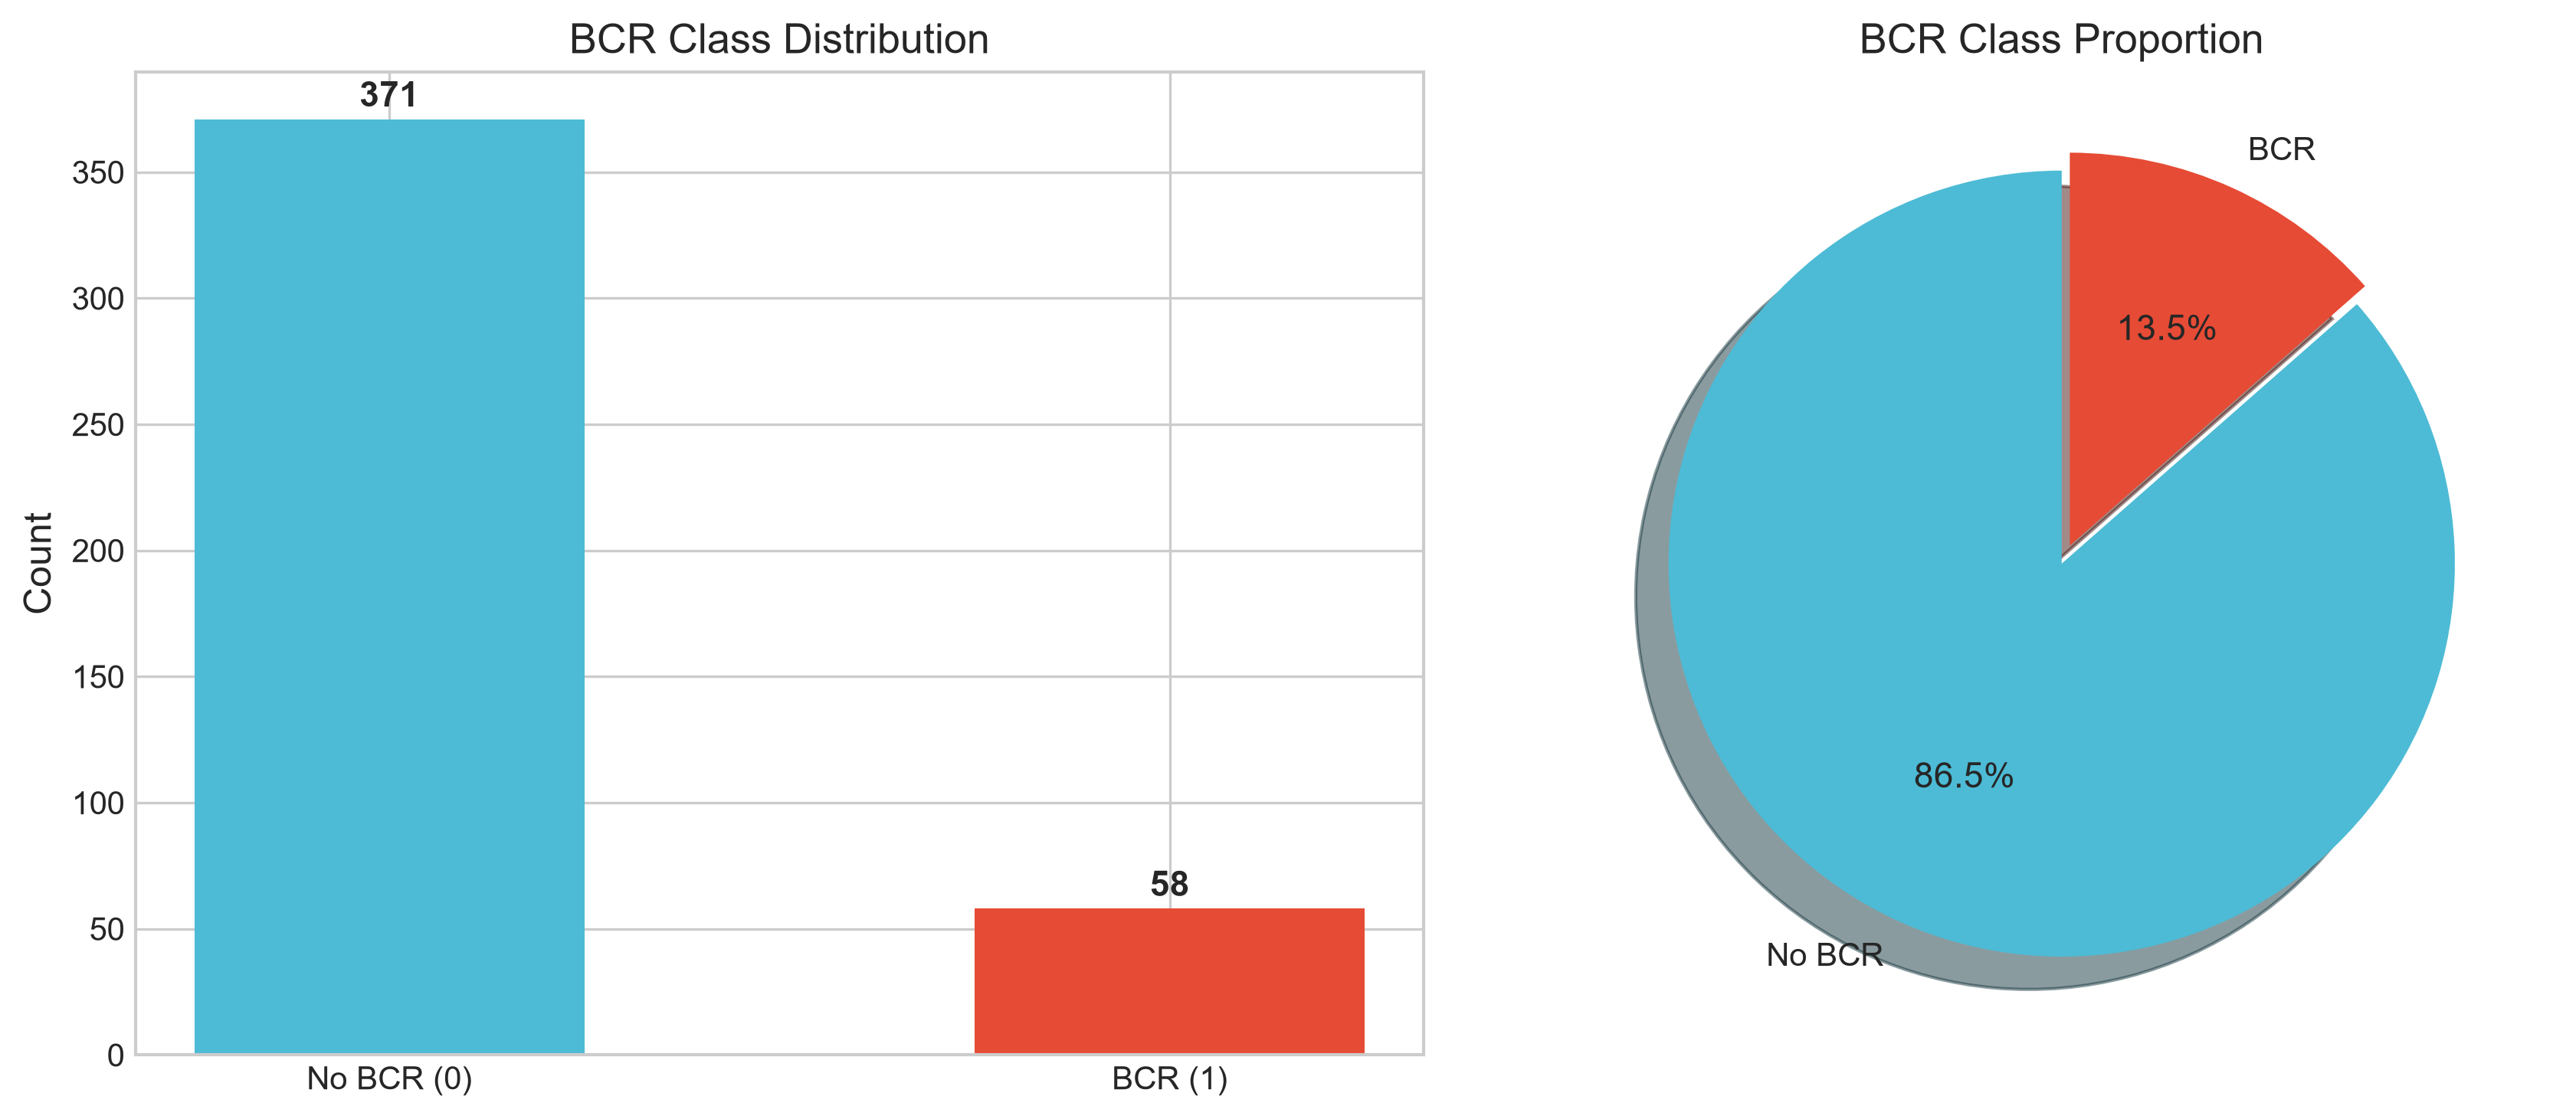

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
counts = y.value_counts().sort_index()
axes[0].bar(["No BCR (0)", "BCR (1)"], counts.values, color=["#4DBBD5", "#E64B35"], width=0.5)
axes[0].set_ylabel("Count")
axes[0].set_title("BCR Class Distribution")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Pie chart
axes[1].pie(counts.values, labels=["No BCR", "BCR"], autopct="%1.1f%%",
            colors=["#4DBBD5", "#E64B35"], startangle=90,
            explode=(0, 0.05), shadow=True)
axes[1].set_title("BCR Class Proportion")

plt.tight_layout()
save_figure(fig, "eda_class_distribution.png")
plt.show()

## Step 4: Feature Type Breakdown (Clinical vs Gene)

2026-09-15 00:03:07 | INFO     | prostate_bcr | Column groups: 115 clinical, 18904 gene
2026-09-15 00:03:07 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\eda_feature_breakdown.png


Clinical features: 115
Gene features:     18904
Total:             19019
Input columns:     19019


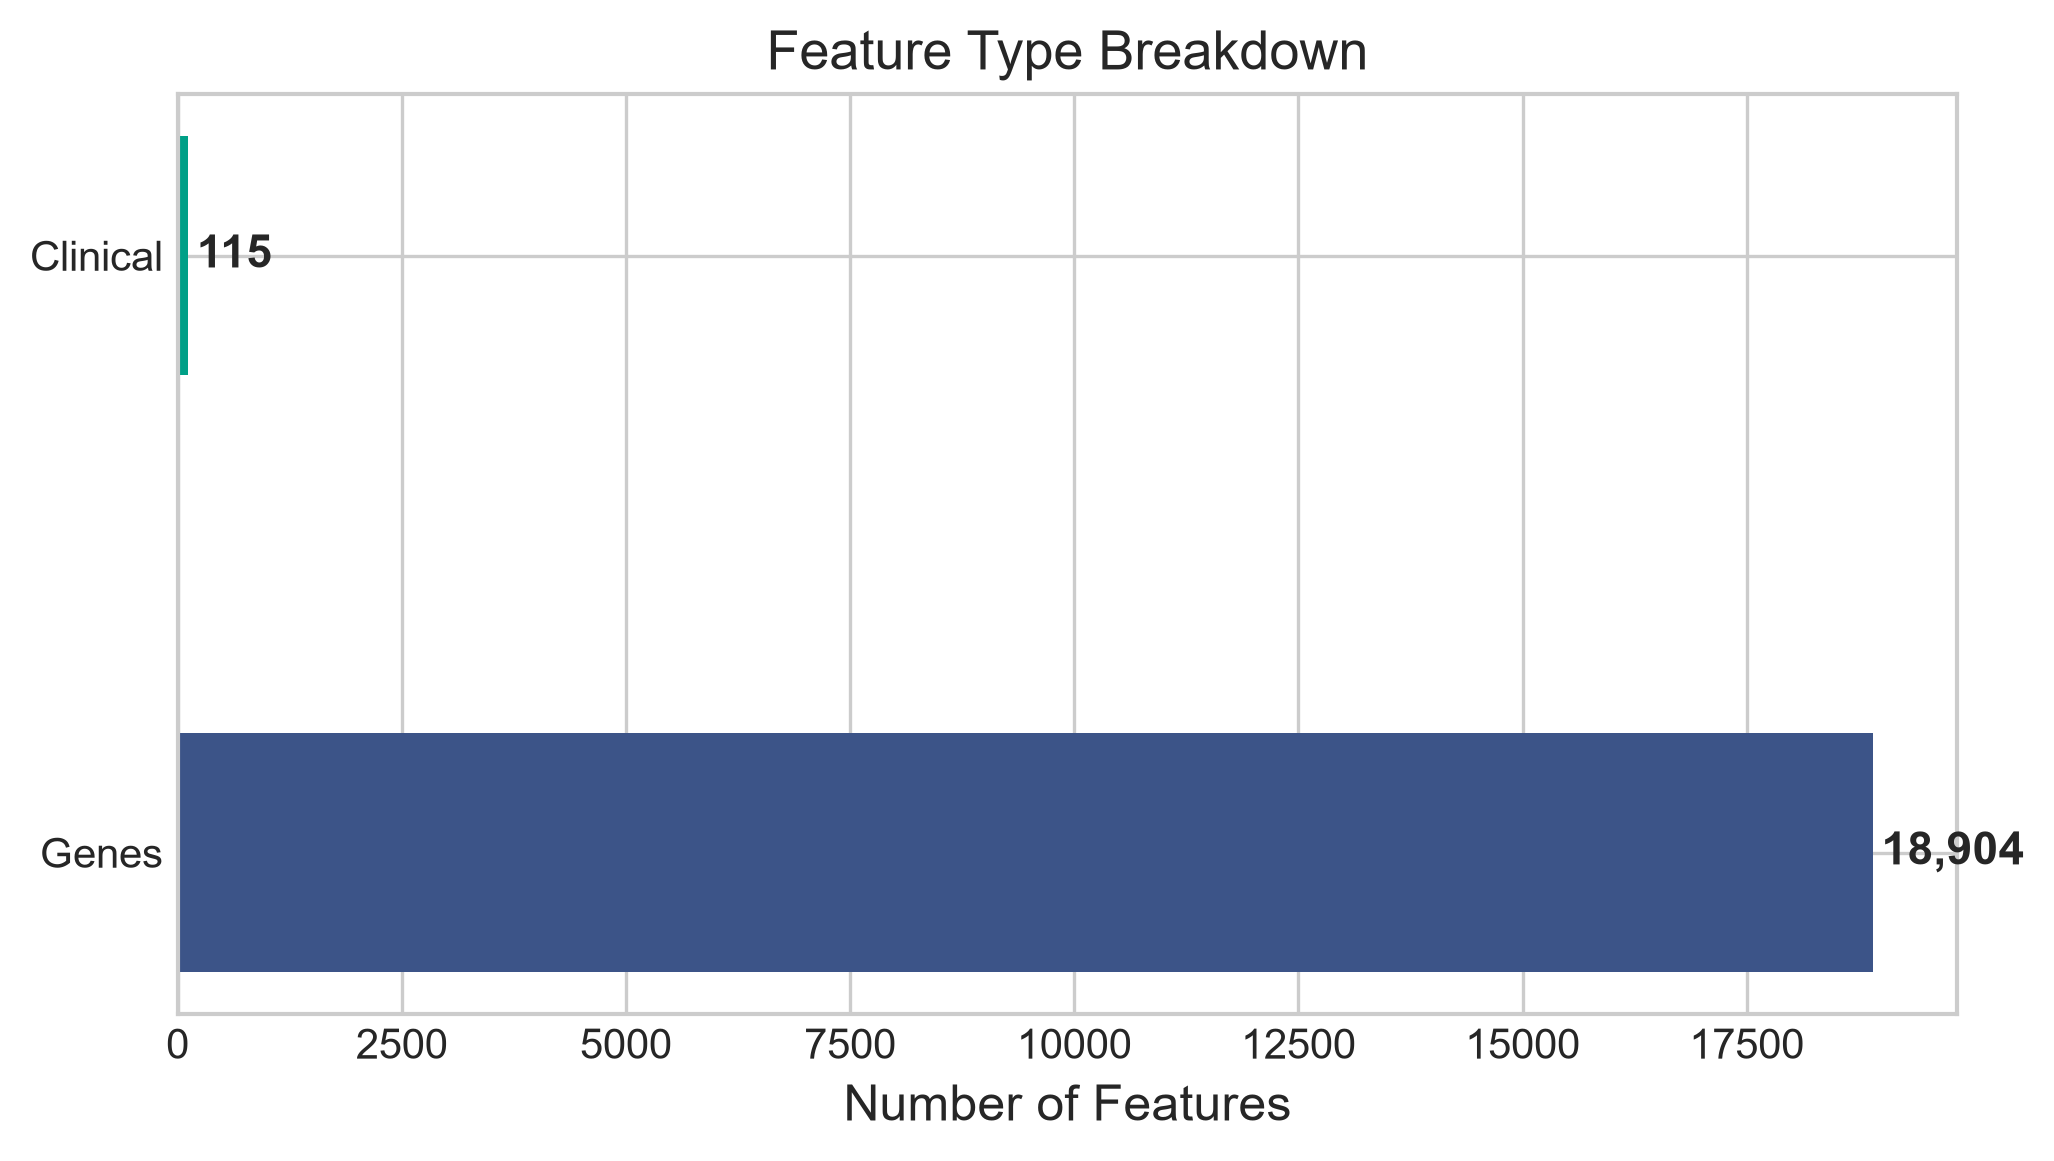

In [5]:
import importlib
import src.preprocessing as preprocessing

preprocessing = importlib.reload(preprocessing)
clinical_cols, gene_cols = preprocessing.identify_column_groups(X)

assert len(clinical_cols) + len(gene_cols) == X.shape[1], (
    "Feature grouping lost columns: "
    f"clinical={len(clinical_cols)}, genes={len(gene_cols)}, "
    f"total={X.shape[1]}"
)

print(f"Clinical features: {len(clinical_cols)}")
print(f"Gene features:     {len(gene_cols)}")
print(f"Total:             {len(clinical_cols) + len(gene_cols)}")
print(f"Input columns:     {X.shape[1]}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(["Genes", "Clinical"], [len(gene_cols), len(clinical_cols)],
        color=["#3C5488", "#00A087"], height=0.4)
ax.set_xlabel("Number of Features")
ax.set_title("Feature Type Breakdown")
for i, v in enumerate([len(gene_cols), len(clinical_cols)]):
    ax.text(v + 100, i, f"{v:,}", va="center", fontweight="bold")
plt.tight_layout()
save_figure(fig, "eda_feature_breakdown.png")
plt.show()

## Step 5: Clinical Feature Distributions

2026-09-15 00:03:09 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\eda_clinical_distributions.png


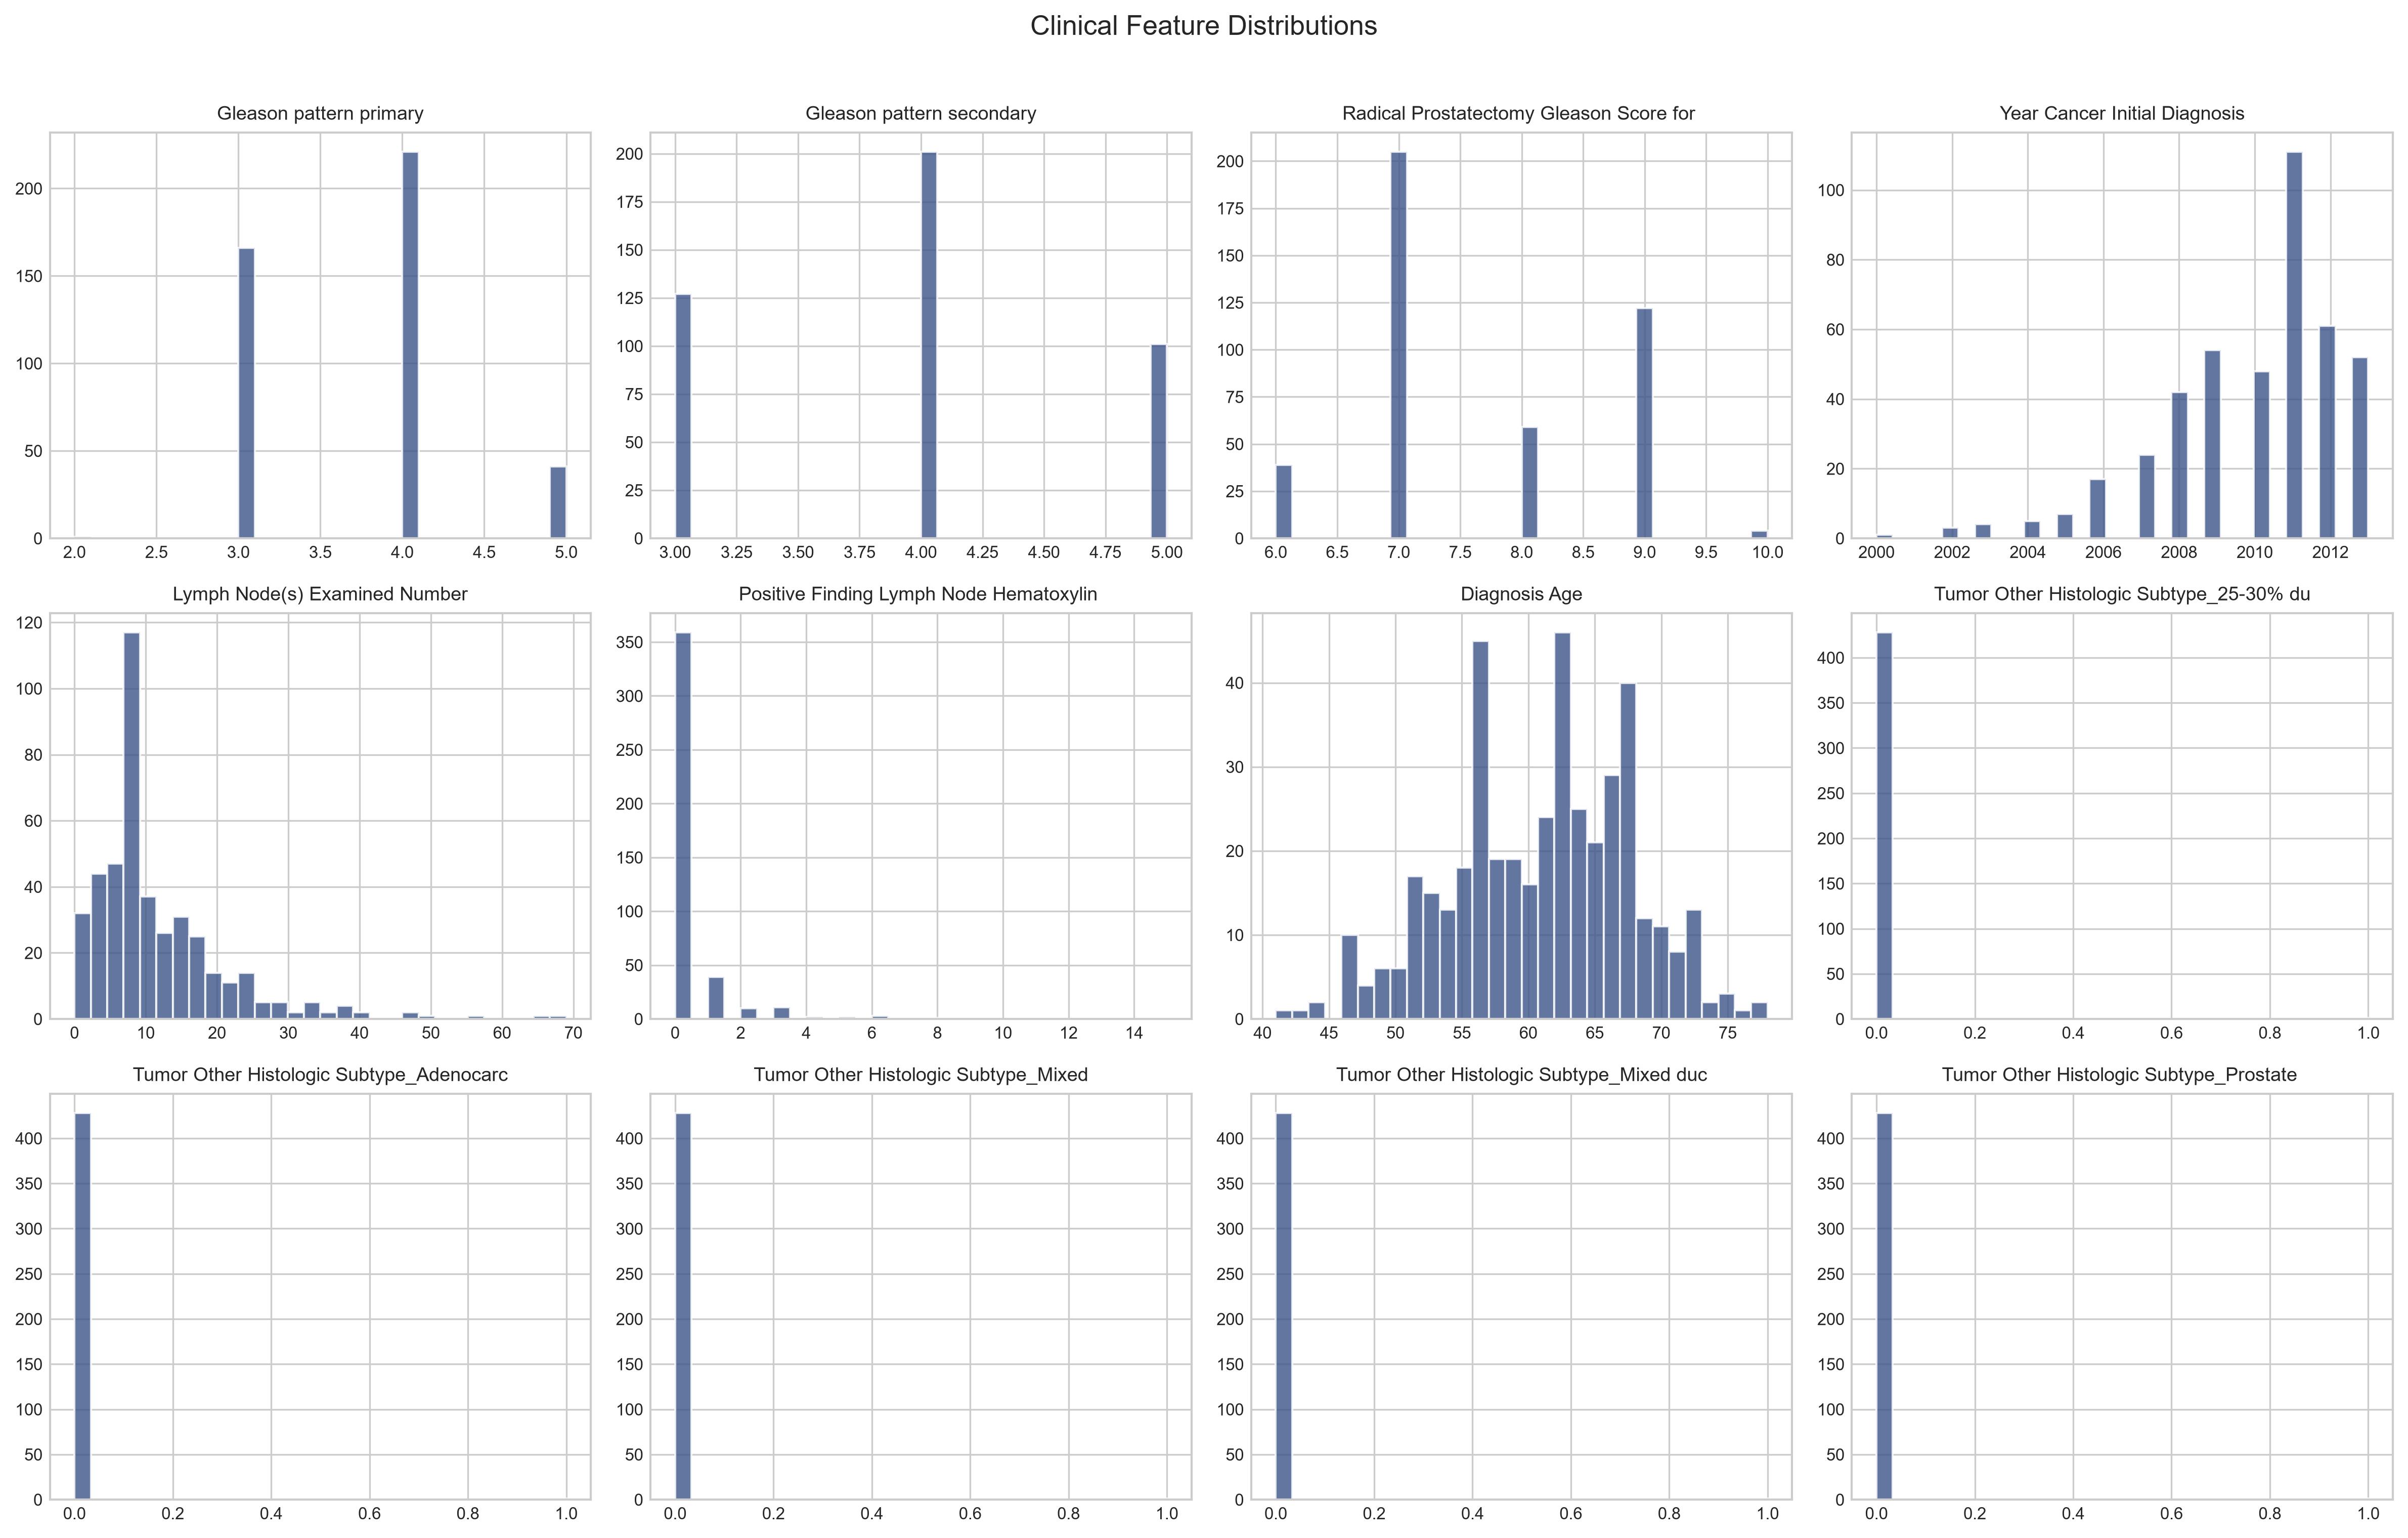

In [6]:
clinical_numeric = X[clinical_cols].select_dtypes(include=[np.number])
n_show = min(12, len(clinical_numeric.columns))

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(clinical_numeric.columns[:n_show]):
    axes[i].hist(clinical_numeric[col].dropna(), bins=30, color="#3C5488",
                 edgecolor="white", alpha=0.8)
    axes[i].set_title(col[:40], fontsize=9)
    axes[i].tick_params(labelsize=8)

for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Clinical Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
save_figure(fig, "eda_clinical_distributions.png")
plt.show()

## Step 6: Gene Expression Overview

Gene expression statistics:
       mean_expression  std_expression  median_expression   pct_zero
count        18904.000       18904.000          18904.000  18904.000
mean          1046.028         524.429            942.557      0.069
std           4457.712        2726.662           4055.959      0.189
min              0.039           0.230              0.000      0.000
25%             30.329          31.944             18.482      0.000
50%            291.461         141.672            254.098      0.000
75%            977.099         384.806            898.658      0.002
max         425916.570      244684.336         395527.309      0.972


2026-09-15 00:03:13 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\eda_gene_expression_overview.png


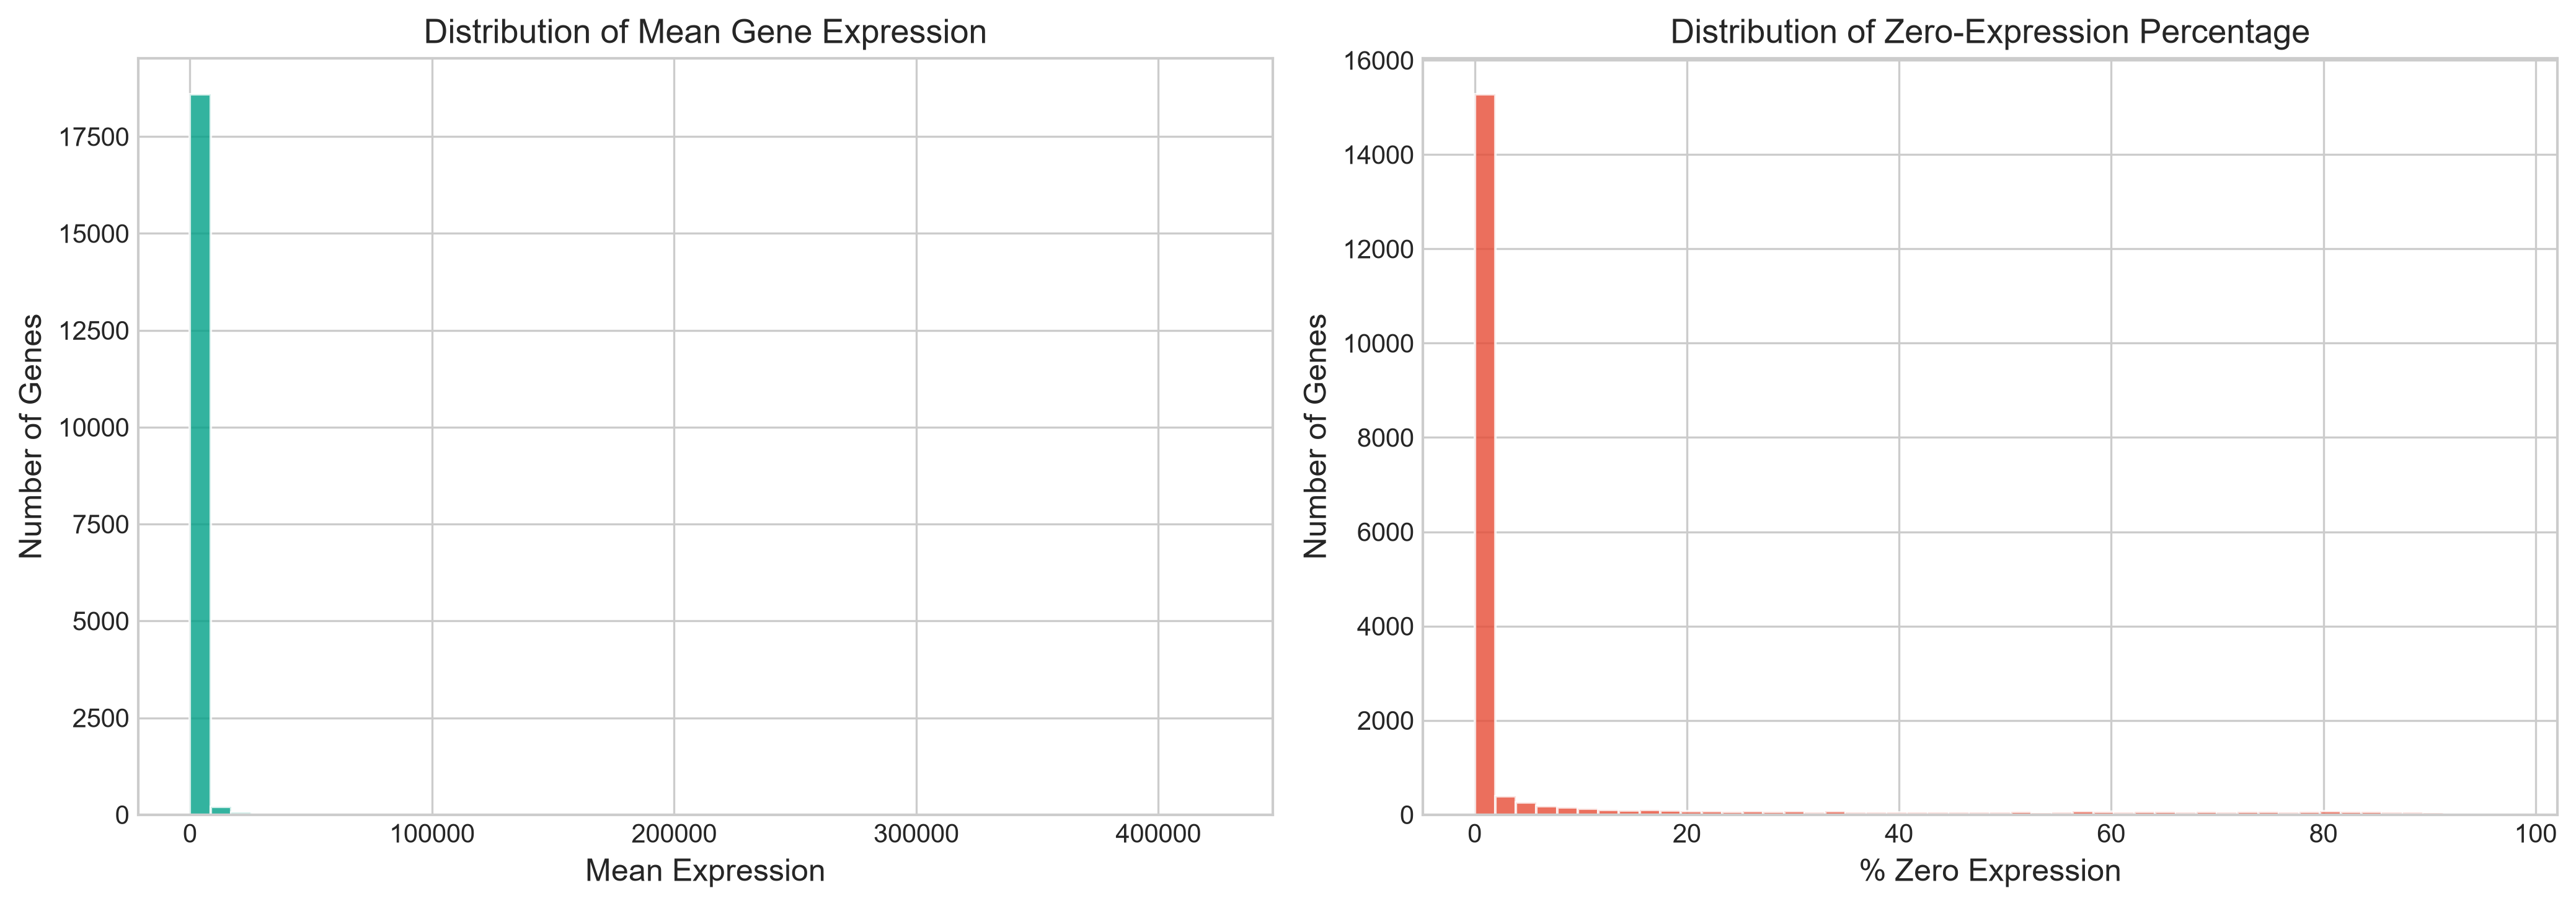

In [7]:
gene_data = X[gene_cols]

gene_stats = pd.DataFrame({
    "mean_expression": gene_data.mean(),
    "std_expression": gene_data.std(),
    "median_expression": gene_data.median(),
    "pct_zero": (gene_data == 0).mean(),
})

print("Gene expression statistics:")
print(gene_stats.describe().round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean expression distribution
axes[0].hist(gene_stats["mean_expression"], bins=50, color="#00A087",
             edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Mean Expression")
axes[0].set_ylabel("Number of Genes")
axes[0].set_title("Distribution of Mean Gene Expression")

# Percentage of zero expression
axes[1].hist(gene_stats["pct_zero"] * 100, bins=50, color="#E64B35",
             edgecolor="white", alpha=0.8)
axes[1].set_xlabel("% Zero Expression")
axes[1].set_ylabel("Number of Genes")
axes[1].set_title("Distribution of Zero-Expression Percentage")

plt.tight_layout()
save_figure(fig, "eda_gene_expression_overview.png")
plt.show()

## Step 7: Top Variable Genes by Variance

2026-09-15 00:03:14 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\eda_top_variance_genes.png


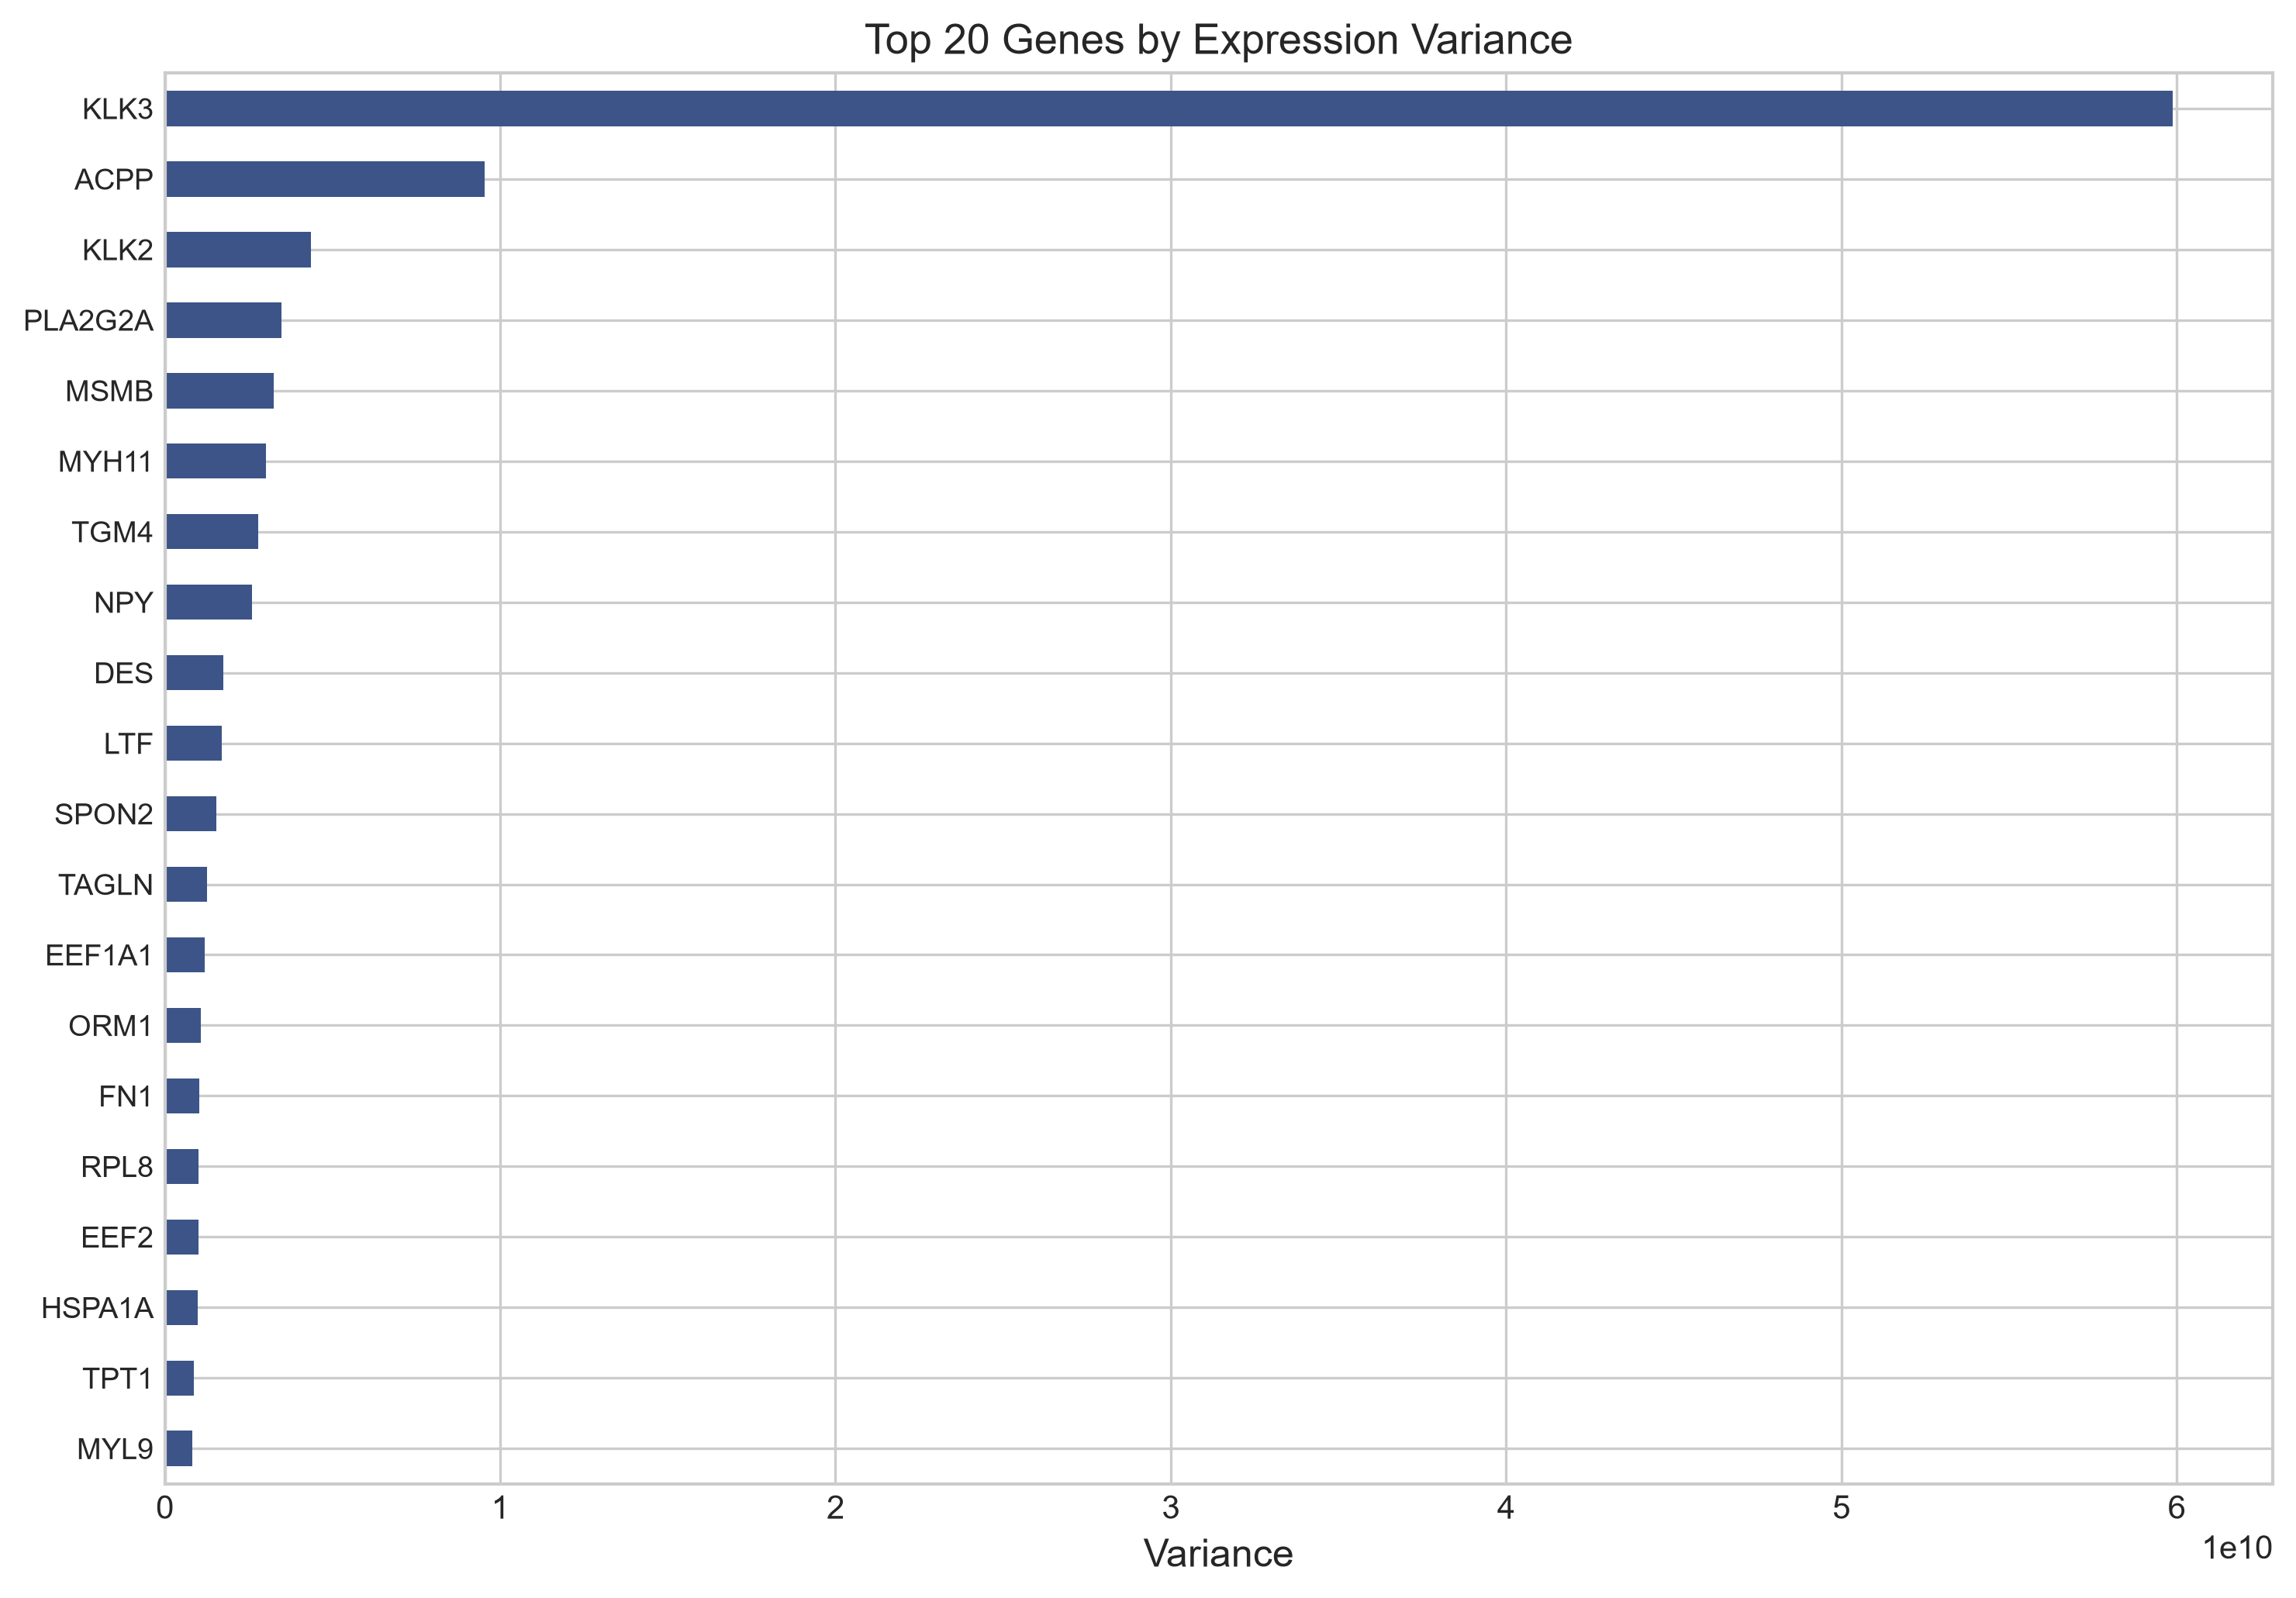

Top 10 highest-variance genes:
KLK3       5.987042e+10
ACPP       9.536639e+09
KLK2       4.346694e+09
PLA2G2A    3.481086e+09
MSMB       3.243426e+09
MYH11      3.008057e+09
TGM4       2.791804e+09
NPY        2.594355e+09
DES        1.745201e+09
LTF        1.699869e+09
dtype: float64


In [8]:
gene_variances = gene_data.var().sort_values(ascending=False)
top_var_genes = gene_variances.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_var_genes.sort_values().plot(kind="barh", ax=ax, color="#3C5488")
ax.set_xlabel("Variance")
ax.set_title("Top 20 Genes by Expression Variance")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
save_figure(fig, "eda_top_variance_genes.png")
plt.show()

print("Top 10 highest-variance genes:")
print(gene_variances.head(10).round(3))

## Step 8: Correlation Heatmap (Top Clinical Features)

2026-09-15 00:03:15 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\eda_clinical_correlation.png


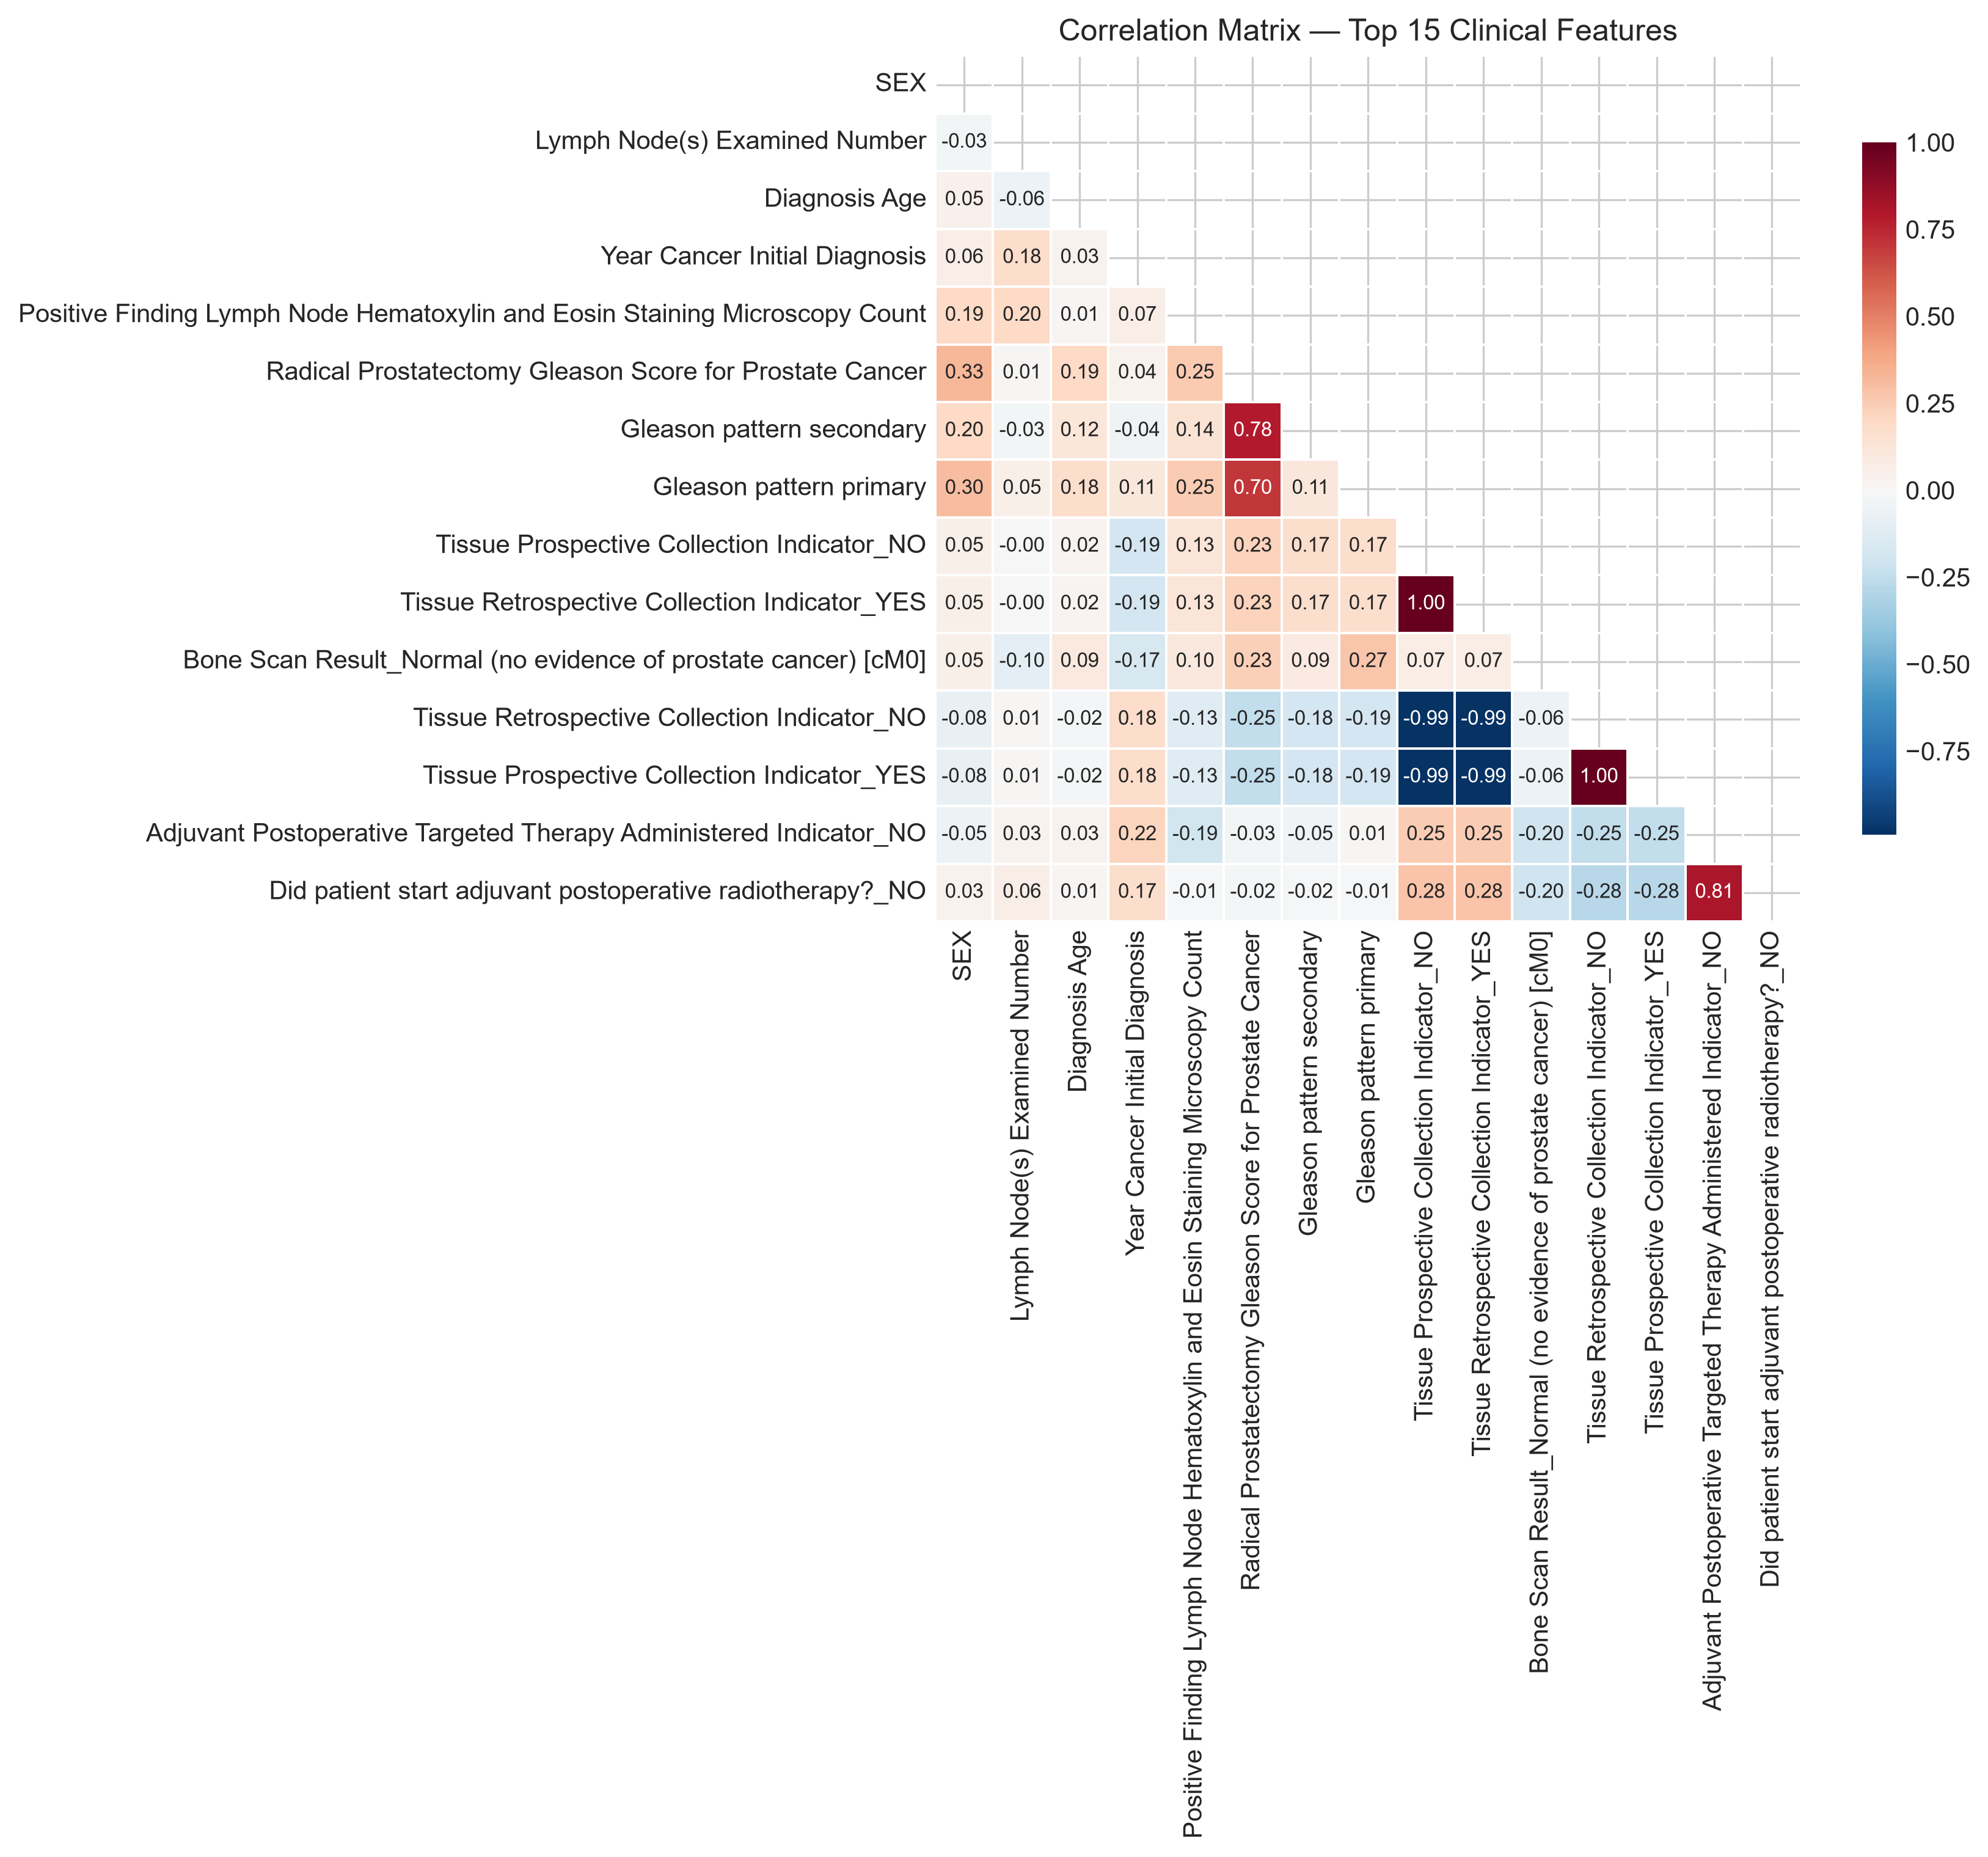

In [9]:
top_clinical = clinical_numeric.var().sort_values(ascending=False).head(15).index.tolist()
corr_matrix = X[top_clinical].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", square=True, ax=ax,
            linewidths=0.5, linecolor="white",
            annot_kws={"size": 8}, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — Top 15 Clinical Features", fontsize=12)
plt.tight_layout()
save_figure(fig, "eda_clinical_correlation.png")
plt.show()

## Step 9: Gene Expression Heatmap by BCR Status

In [10]:
top_genes_for_heatmap = gene_variances.head(30).index.tolist()

fig = plot_gene_heatmap(
    X[top_genes_for_heatmap],
    y,
    top_genes_for_heatmap,
    filename="eda_gene_heatmap_by_bcr.png",
    figsize=(14, 10),
)
plt.show()

2026-09-15 00:03:16 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\eda_gene_heatmap_by_bcr.png
2026-09-15 00:03:16 | INFO     | prostate_bcr | Gene heatmap generated (30 genes)


## Step 10: Missing Value Analysis

In [11]:
missing_per_feature = X.isna().mean()
n_missing = (missing_per_feature > 0).sum()

print(f"Features with missing values: {n_missing} / {X.shape[1]}")
print(f"Total missing cells: {int(X.isna().sum().sum()):,}")

if n_missing > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing_per_feature[missing_per_feature > 0].sort_values(ascending=False).head(20).plot(
        kind="bar", ax=ax, color="#E64B35", edgecolor="white"
    )
    ax.set_ylabel("Fraction Missing")
    ax.set_title("Top 20 Features with Missing Values")
    ax.tick_params(axis="x", labelsize=8, rotation=45)
    plt.tight_layout()
    save_figure(fig, "eda_missing_values.png")
    plt.show()
else:
    print("No missing values detected in the merged dataset.")

Features with missing values: 0 / 19019
Total missing cells: 0
No missing values detected in the merged dataset.


## Step 11: Feature Variance Distribution

2026-09-15 00:03:18 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\eda_variance_distribution.png


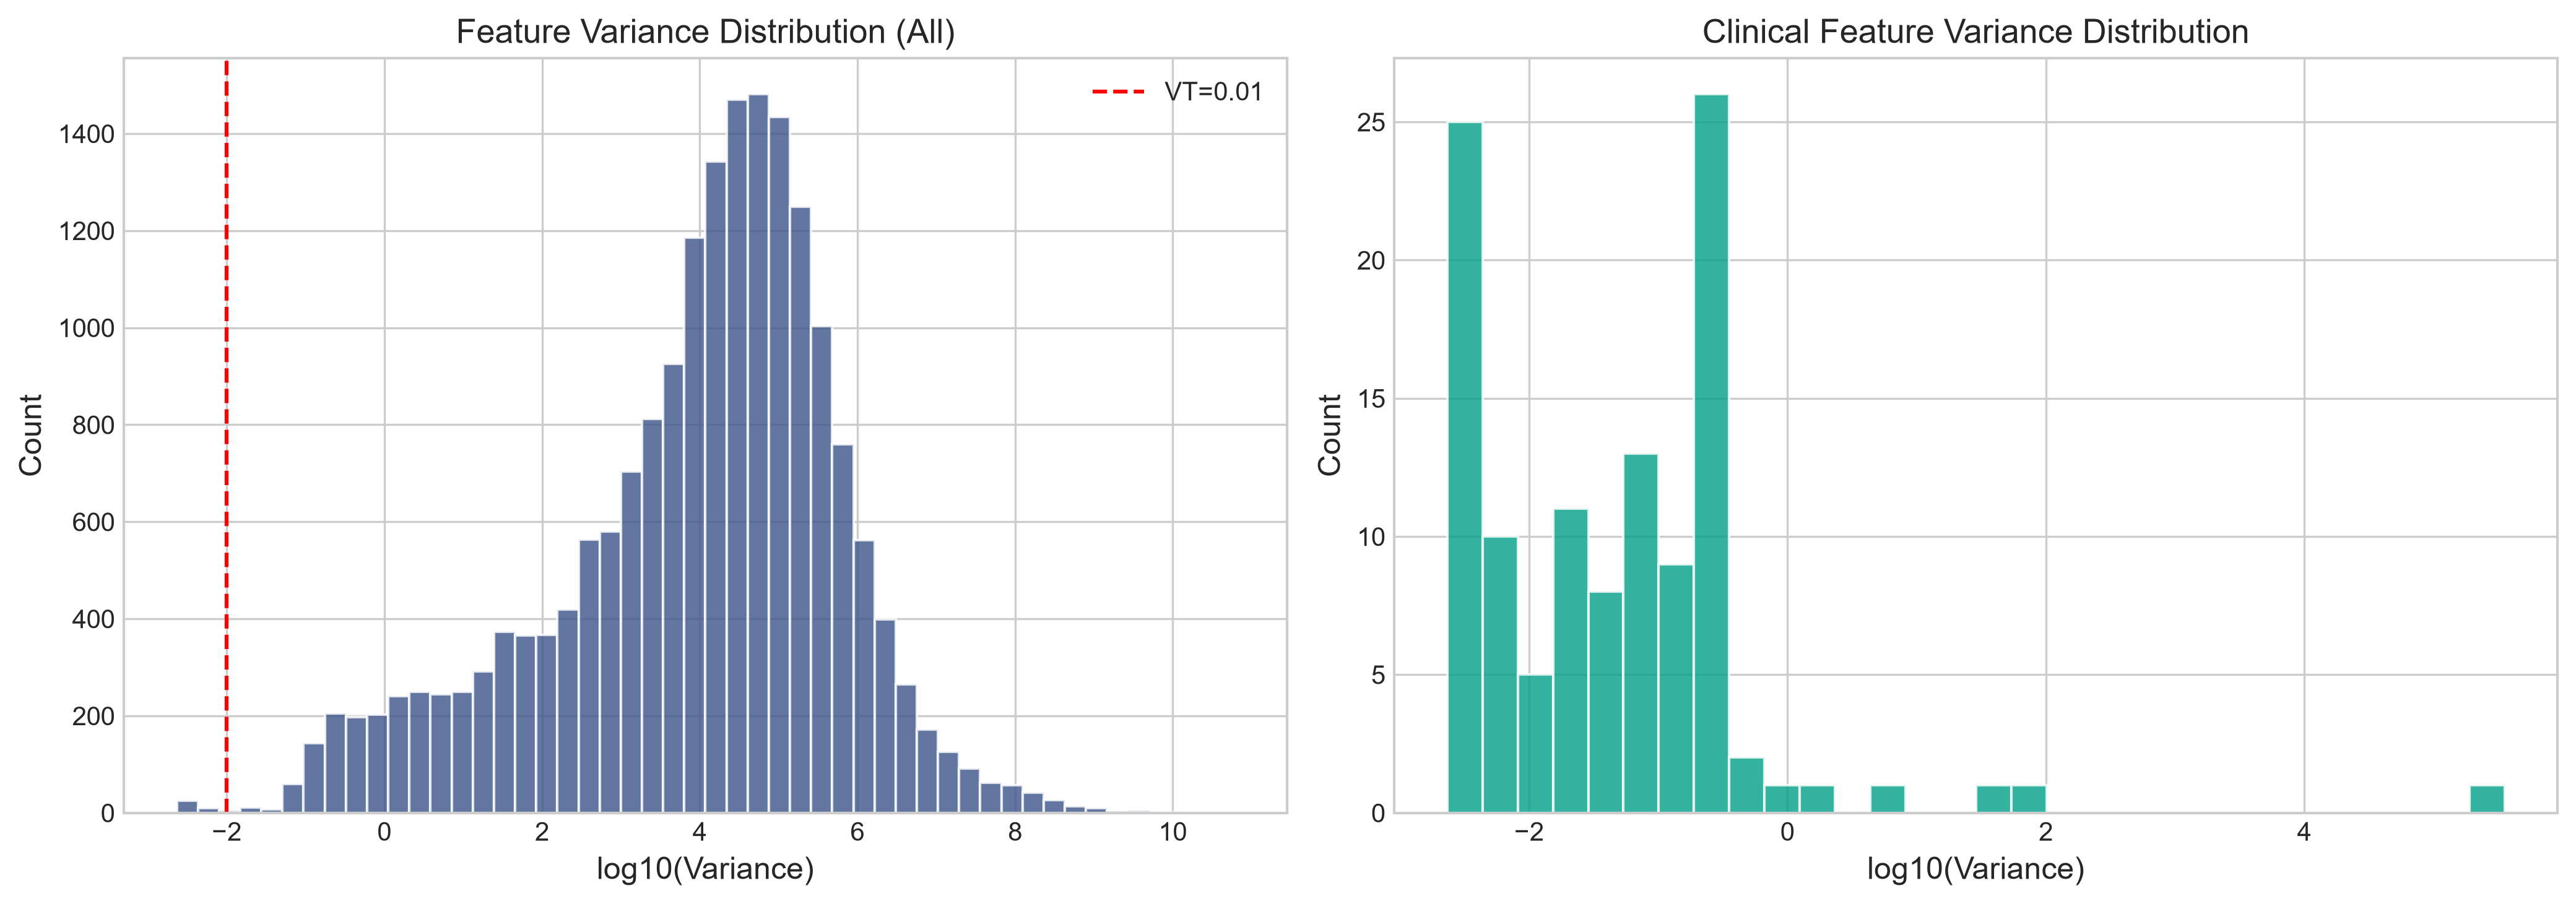


Features below variance threshold (0.01): 38


In [12]:
all_variances = X.var()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All features
axes[0].hist(np.log10(all_variances + 1e-10), bins=50, color="#3C5488",
             edgecolor="white", alpha=0.8)
axes[0].set_xlabel("log10(Variance)")
axes[0].set_ylabel("Count")
axes[0].set_title("Feature Variance Distribution (All)")
axes[0].axvline(np.log10(config.VARIANCE_THRESHOLD), color="red",
                linestyle="--", label=f"VT={config.VARIANCE_THRESHOLD}")
axes[0].legend()

# Clinical only
clinical_var = X[clinical_cols].var()
axes[1].hist(np.log10(clinical_var + 1e-10), bins=30, color="#00A087",
             edgecolor="white", alpha=0.8)
axes[1].set_xlabel("log10(Variance)")
axes[1].set_ylabel("Count")
axes[1].set_title("Clinical Feature Variance Distribution")

plt.tight_layout()
save_figure(fig, "eda_variance_distribution.png")
plt.show()

n_below_vt = (all_variances < config.VARIANCE_THRESHOLD).sum()
print(f"\nFeatures below variance threshold ({config.VARIANCE_THRESHOLD}): {n_below_vt}")

In [13]:
from src.io import save_table

summary = pd.DataFrame({
    "metric": [
        "n_samples", "n_features", "n_clinical_features", "n_gene_features",
        "n_positive", "n_negative", "positive_rate",
        "n_missing_cells", "n_features_below_vt",
    ],
    "value": [
        len(X), X.shape[1], len(clinical_cols), len(gene_cols),
        int(y.sum()), int((y == 0).sum()), f"{y.mean():.2%}",
        int(X.isna().sum().sum()), int((all_variances < config.VARIANCE_THRESHOLD).sum()),
    ],
})
save_table(summary, "eda_summary.csv", index=False)
print("EDA summary saved to outputs/tables/eda_summary.csv")

2026-09-15 00:03:18 | INFO     | prostate_bcr | Saved 9 rows → D:\Prostate_BCR\core\outputs\tables\eda_summary.csv


EDA summary saved to outputs/tables/eda_summary.csv
